# Data Wrangling (¡Llena ese carrito!)

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [ ]:
# importar librerías
import pandas as pd

In [ ]:
# leer conjuntos de datos en los DataFrames
instacard_df = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products_df = pd.read_csv('/datasets/products.csv', sep=';')
order_products_df = pd.read_csv('/datasets/order_products.csv', sep=';')
aisles_df = pd.read_csv('/datasets/aisles.csv', sep=';')
department_df = pd.read_csv('/datasets/departments.csv', sep=';')

In [ ]:
# mostrar información del DataFrame
instacard_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [ ]:
# mostrar información del DataFrame
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
# mostrar información del DataFrame
order_products_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [ ]:
# mostrar información del DataFrame
aisles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
# mostrar información del DataFrame
department_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


## Conclusiones

Inicialmente se puede observar tras una primera ejecución del método info que los datos csv no están separados por comas como lo es el standar, sino que están separados por 'punto y coma'. Por lo tanto para poder obtener una muestra más precisa de los datos de la hoja de cálculo, es necesario indicar el tipo de separador correcto con la propiedad 'sep' y así poder ver la cantidad de columas y filas que contiene cada documento.


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

El plan es identificar los tipos de datos de cada df y realizar als conversiones necesarias. Así mismo, veririficar valores duplicados y valores ausentes para su reemplazo o eliminación.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Es correcto que abordes primero los valores duplicados antes de llenar los valores ausentes. Si eliminas duplicados después, podrías haber trabajado innecesariamente en filas que no eran relevantes para el análisis. Esto te permite ahorrar tiempo y esfuerzo mientras aseguras que los datos sean consistentes desde el principio.

</div>

### `orders` data frame

In [ ]:
# Revisa si hay pedidos duplicados
instacard_df.value_counts()
#instacard_df[instacard_df.duplicated()]

order_id  user_id  order_number  order_dow  order_hour_of_day  days_since_prior_order
1021560   53767    3             3          2                  9.0                       2
467134    63189    21            3          2                  2.0                       2
391768    57671    19            3          2                  10.0                      2
2282673   86751    49            3          2                  2.0                       2
408114    68324    4             3          2                  18.0                      2
                                                                                        ..
1141863   88987    2             1          11                 14.0                      1
1141854   125458   91            6          8                  2.0                       1
1141847   156072   4             2          21                 6.0                       1
1141845   153218   2             3          8                  6.0                       1
3421

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común? Que todos ellos se hicieron el día miércoles a las 2 pm

In [ ]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.


¿Qué sugiere este resultado?

In [ ]:
# Elimina los pedidos duplicados
instacard_df.drop_duplicates(inplace=True)

In [ ]:
# Vuelve a verificar si hay filas duplicadas
instacard_df[instacard_df.duplicated()].count()

order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

In [ ]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
instacard_df['order_id'].duplicated().sum()

0

Después de haber borrado las filas duplicadas, ahora podemos ver que tanto verificando el df completo así como filtrándolo por el id, ya no existen duplicados.

### `products` data frame

In [ ]:
# Verifica si hay filas totalmente duplicadas
products_df.value_counts()

product_id  product_name                                       aisle_id  department_id
1           Chocolate Sandwich Cookies                         61        19               1
33112       Krinkle Cut Carolina BBQ Potato Chips              107       19               1
33103       Fresh Ground Turkey- 85% Lean/15% Fat              35        12               1
33104       Organic Unsweetened Ketchup                        72        13               1
33105       French Vanilla Concentrated Liquid Coffee Creamer  53        16               1
                                                                                         ..
16570       Organic Fresh Carrot Chips                         123       4                1
16571       Unbleached Jumbo Baking Cups                       97        13               1
16572       Super Glue Gel Control                             87        17               1
16573       3 Cheese Ravioli                                   38        1           

In [ ]:
# Revisa únicamente si hay ID de productos duplicados
products_df['product_id'].duplicated().sum()

0

In [ ]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products_df['product_name'] = products_df['product_name'].str.upper().str.strip()
products_df['product_name'].duplicated().sum()

1361

In [ ]:
# Revisa si hay nombres duplicados de productos no faltantes
print(products_df[products_df['product_name'].duplicated(keep=False)==True & products_df['product_name'].notna()].sort_values(by="product_name"))
#products_df['product_name'].value_counts()

       product_id                               product_name  aisle_id  \
23339       23340  18-IN-1 HEMP PEPPERMINT PURE-CASTILE SOAP        25   
31844       31845  18-IN-1 HEMP PEPPERMINT PURE-CASTILE SOAP        25   
19941       19942            AGED BALSAMIC VINEGAR OF MODENA        19   
13152       13153            AGED BALSAMIC VINEGAR OF MODENA        19   
24830       24831         ALBACORE SOLID WHITE TUNA IN WATER        95   
...           ...                                        ...       ...   
46873       46874                         VITAMIN D3 5000 IU        47   
21366       21367              WILD SARDINES IN SPRING WATER        95   
40093       40094              WILD SARDINES IN SPRING WATER        95   
1826         1827           YAMS CUT SWEET POTATOES IN SYRUP        81   
38260       38261           YAMS CUT SWEET POTATOES IN SYRUP        81   

       department_id  
23339             11  
31844             11  
19941             13  
13152             1

Después de tomar la columna 'product_name' y pasar todo a mayúscula y quitar espacios en blanco, noté que efectivamente hay duplicados. Sin embargo, es probable que en las demás tablas estos productos duplicados con id distinto estén siendo utilizados por lo que he decidido dejarlos como tal. Una posible solución sería realizar un reemplazo de los id por un único pero correría el riesgo de perder datos.

### `departments` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
department_df.duplicated().sum()

0

In [ ]:
# Revisa únicamente si hay IDs duplicadas de departamentos
department_df['department_id'].duplicated().sum()

0

Por lo visto, no hay filas duplicadas en este df.

### `aisles` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
aisles_df.duplicated().sum()

0

In [ ]:
# Revisa únicamente si hay IDs duplicadas de pasillos
aisles_df['aisle_id'].duplicated().sum()

0

Por lo visto, no hay filas duplicadas en este df.

### `order_products` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
order_products_df.duplicated().sum()

0

In [ ]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
order_products_df.value_counts()

order_id  product_id  add_to_cart_order  reordered
4         10054       5.0                1            1
2277733   35233       5.0                1            1
2277734   15233       4.0                1            1
          11471       2.0                1            1
          6374        3.0                1            1
                                                     ..
1145037   26790       21.0               1            1
          27767       10.0               1            1
          32086       16.0               0            1
          33572       5.0                1            1
3421079   30136       1.0                0            1
Length: 4544171, dtype: int64

Hay duplicados en los id's pero es normal debido a que una orden contiene varios productos.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [ ]:
# Encuentra los valores ausentes en la columna 'product_name'
products_df['product_name'].isna().sum()

1258

En 'product_name' encontré 1258 valores ausentes.

In [ ]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
#products_df['product_name'].isna().sum()

print(products_df[products_df['product_name']
    .isna()]
    .groupby('aisle_id').size()
    .reset_index(name='count'))

   aisle_id  count
0       100   1258


Si, todos.

In [ ]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print(products_df[products_df['product_name'].isna()
    & (products_df['aisle_id']==100)
    & (products_df['department_id']==21)])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Si. Todos.

In [ ]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(aisles_df[aisles_df['aisle_id'] == 100])
print()
print(department_df[department_df['department_id'] == 21])

    aisle_id    aisle
99       100  missing

    department_id department
20             21    missing


En base a los df department y aisle, se puede ibservar que los id's mencionados están con valores de missing.

In [ ]:
# Completa los nombres de productos ausentes con 'Unknown'
products_df['product_name'].fillna('Unknown', inplace=True)
print(products_df[products_df['product_name'].isna()])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Después de llenar los nombres vaciós, vemos como ahora ya todos los datos de la columna 'product_name' tienen valores

### `orders` data frame

In [ ]:
# Encuentra los valores ausentes
print(instacard_df[instacard_df['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [ ]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print(instacard_df[instacard_df['days_since_prior_order'].isna() & (instacard_df['order_number'] > 1)])

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Los valores ausentes que encontramos en este df se encuentran en la columna 'days_since_prior_order' y sólo están cuando son la primera compra por lo que eso es correcto.

### `order_products` data frame

In [ ]:
# Encuentra los valores ausentes
print(order_products_df[order_products_df['add_to_cart_order'].isna()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [ ]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print('Min value:',order_products_df['add_to_cart_order'].min())

print('Max value:',order_products_df['add_to_cart_order'].max())

Min value: 1.0
Max value: 64.0


el valor máximo encontrado es 64, pero se ven, tal como se mostraba en el 'info' que esa columna tiene el tipo float cuando debe ser int

In [ ]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
order_product_ids = order_products_df[order_products_df['add_to_cart_order'].isna()][['order_id', 'product_id']]
print(order_product_ids)

         order_id  product_id
737       2449164        5068
9926      1968313       43867
14394     2926893       11688
16418     1717990        4142
30114     1959075       42828
...           ...         ...
4505662   1800005        7411
4511400   1633337         260
4517562    404157        9517
4534112   1673227       17835
4535739   1832957       17949

[836 rows x 2 columns]


In [ ]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
counts = order_product_ids.groupby('order_id')['product_id'].count()
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
counts = counts.sort_values()
print(counts)

order_id
9310        1
747668      1
1598369     1
1677118     1
2170451     1
           ..
1959075    34
171934     40
2136777    44
3308010    51
61355      63
Name: product_id, Length: 70, dtype: int64


La cuenta de los productos por cada pedido que tiene la columna add_to_card vacía oscila entre 1 a 63.Por lo que a la pregunta inicial, la respuesta es no.

In [ ]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

order_products_df['add_to_cart_order'].fillna(999, inplace=True)
order_products_df['add_to_cart_order'] = order_products_df['add_to_cart_order'].astype(int)
order_products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


Luego de haber llenado los valores vacíos con el número 999 ya pudimos cambiar el tipo de dato a int. Con ya se podrían hacer cálculos más adelante
o incluisve trabajar con gráficos.

## Conclusiones
Me parece super bueno que ya estemos aplicando lo que hemos estudiado anteriormente en un caso más real e integral. El caso tiene varias tablas y a la vez varios de los errores vistos en las clases. Iniciamos con valores duplicados y luego con valores nulos. Interesante igual lo de agrupar debido a que una orden tiene varios productos y en base a eso poder luego reemplazar los valores perdidos por 'unknown'. Finalmente también la ultima parte que contenía valores nulos en la columna de la orden del carrito, en los cuales se reemplazó por 999 para así poder mantener los valores y a la vez facilitar más adelante otros análisis con el cambio del tipo de dato.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [ ]:

print('order_hour_of_day value min:',instacard_df['order_hour_of_day'].min())
print('order_hour_of_day value min:',instacard_df['order_hour_of_day'].max())


order_hour_of_day value min: 0
order_hour_of_day value min: 23


In [ ]:
print('order_dow value min:',instacard_df['order_dow'].min())
print('order_dow value min:',instacard_df['order_dow'].max())

order_dow value min: 0
order_dow value min: 6


De acuerdo a lo especificado, los rangos son correctos.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [ ]:
print(instacard_df.groupby('order_hour_of_day')['user_id'].count())

order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: user_id, dtype: int64


Por lo que se ve, a partir de la noche, específicamente desde las 22 hay una caída notable. Luego a partir de las 7 am vemos nuevamente un mayor movimiento.

### [A3] ¿Qué día de la semana compran víveres las personas?

In [ ]:
orders_by_day = instacard_df['order_dow'].value_counts().sort_index()
print(orders_by_day)

0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64


Vemos que las personas compran a diario, pero vemos así mismo que los días donde más se suele comprar son los días domingos y lunes. Por otro lado el día de menor compra son los jueves.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

In [ ]:
days_since_prior_order = instacard_df.groupby('days_since_prior_order')['user_id'].count()
print(days_since_prior_order)

days_since_prior_order
0.0      9589
1.0     20179
2.0     27138
3.0     30224
4.0     31006
5.0     30096
6.0     33930
7.0     44577
8.0     25361
9.0     16753
10.0    13309
11.0    11467
12.0    10658
13.0    11737
14.0    13992
15.0     9416
16.0     6587
17.0     5498
18.0     4971
19.0     4939
20.0     5302
21.0     6448
22.0     4514
23.0     3337
24.0     3015
25.0     2711
26.0     2640
27.0     2986
28.0     3745
29.0     2673
30.0    51337
Name: user_id, dtype: int64


Acá se pueden ver cosas muy interesantes. Por ejemplo que en la primera semana el número suele elevado, tomando como pico la primera semana exacta y tomando una bajada a la quincena. Por último, vemos otro pico al mes. Esto tiene sentido ya que hay personas que seguramente compran de manera diaria, otros semanal, otros quincenal y por ultimo mensual.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

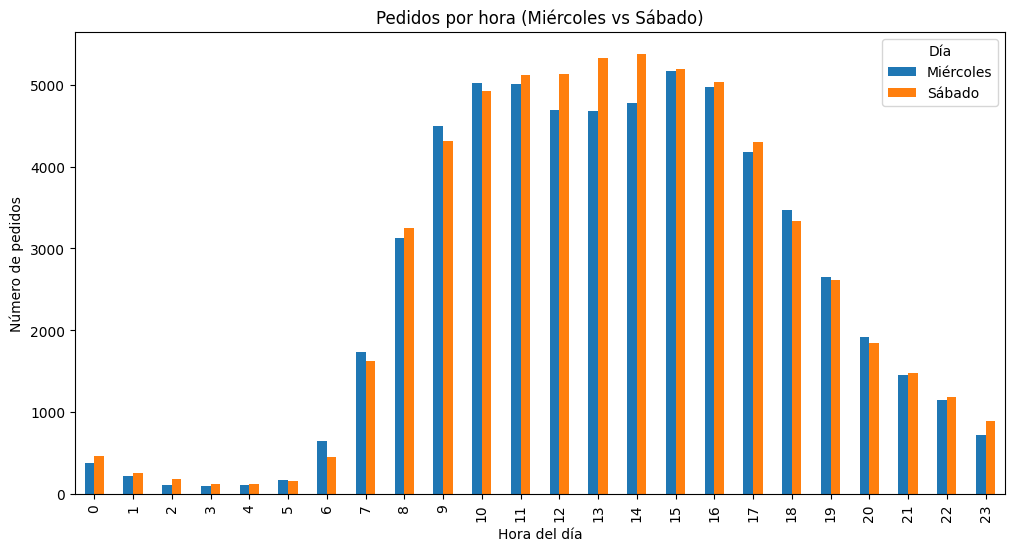

In [ ]:
import matplotlib.pyplot as plt

# Filtrar solo miércoles (3) y sábado (6)
days = [3, 6]
instacard_filtered = instacard_df[instacard_df['order_dow'].isin(days)]


# Agrupar por día de la semana y hora del día
orders_by_hour = instacard_filtered.groupby(['order_dow','order_hour_of_day']).size().unstack(fill_value=0)


# Renombrar días
orders_by_hour.index = orders_by_hour.index.map({3: "Miércoles", 6: "Sábado"})

# Gráfico de barras comparativas
orders_by_hour.T.plot(kind="bar", figsize=(12,6))

plt.title("Pedidos por hora (Miércoles vs Sábado)")
plt.xlabel("Hora del día")
plt.ylabel("Número de pedidos")
plt.legend(title="Día")
plt.show()

Se puede concluir que los días sábados por la tarde, las personas suelen realizar más compras que los miércoles. Por la mañanna, por el otro lado, suele comprarse más los miercoles.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [ ]:

orders_per_customer = instacard_df.groupby("user_id")["order_number"].max()
distribution = orders_per_customer.value_counts().sort_index()


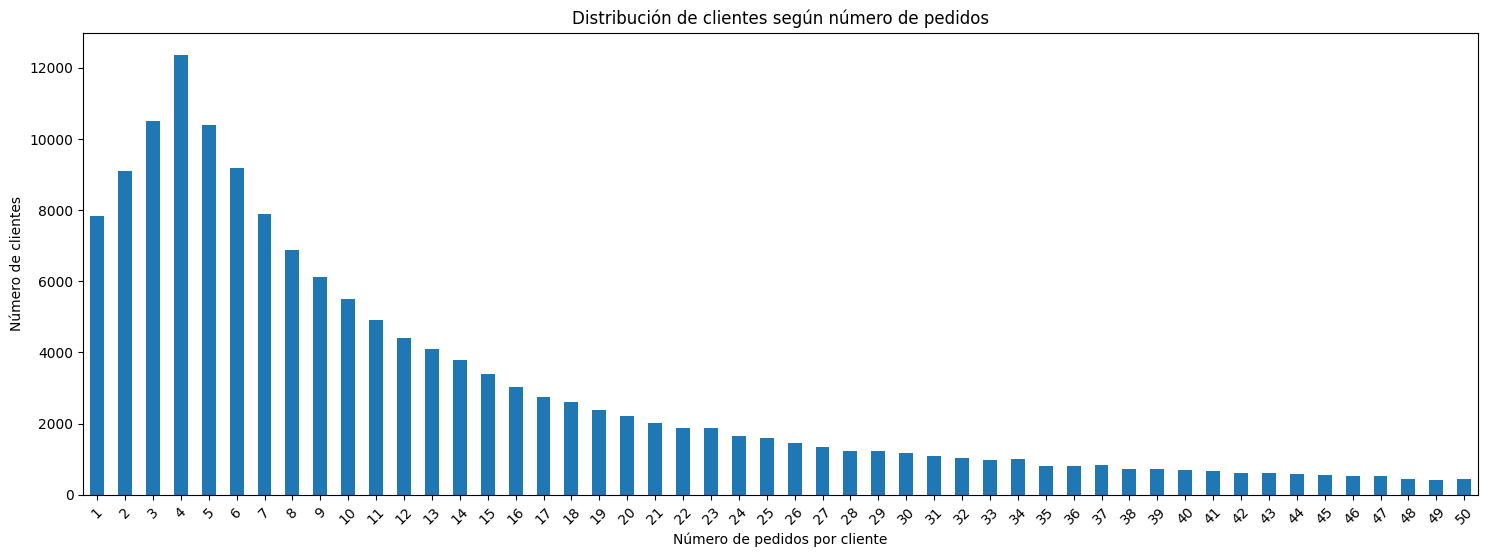

In [ ]:

import matplotlib.pyplot as plt
distribution[distribution.index <= 50].plot(kind="bar", figsize=(18,6))
plt.xlabel("Número de pedidos por cliente")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes según número de pedidos")
plt.xticks(rotation=45)  # ← gira etiquetas 45°
plt.show()


Vemos que el número de personas que hace entre 1 y 2 pedidos es elevado y que no suelen ser clientes recurrentes. Por otro lado, vemos que sí hay muchas personas que han hecho al menos 5 pedidos y luego va bajando su nivel de compras. Es interesante ver qué pasa luego de la 5ta compra en las personas y ver la manera de que la curva siga subiendo con el número de veces que compran. Es decir, que haya más recurrencia.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [ ]:
orders_per_product = order_products_df.groupby("product_id")["order_id"].count()
top20 = orders_per_product.sort_values(ascending=False).head(20).reset_index()

top20 = top20.merge(products_df, on="product_id", how="left")

top20["product_label"] = top20["product_id"].astype(str) + " - " + top20["product_name"]

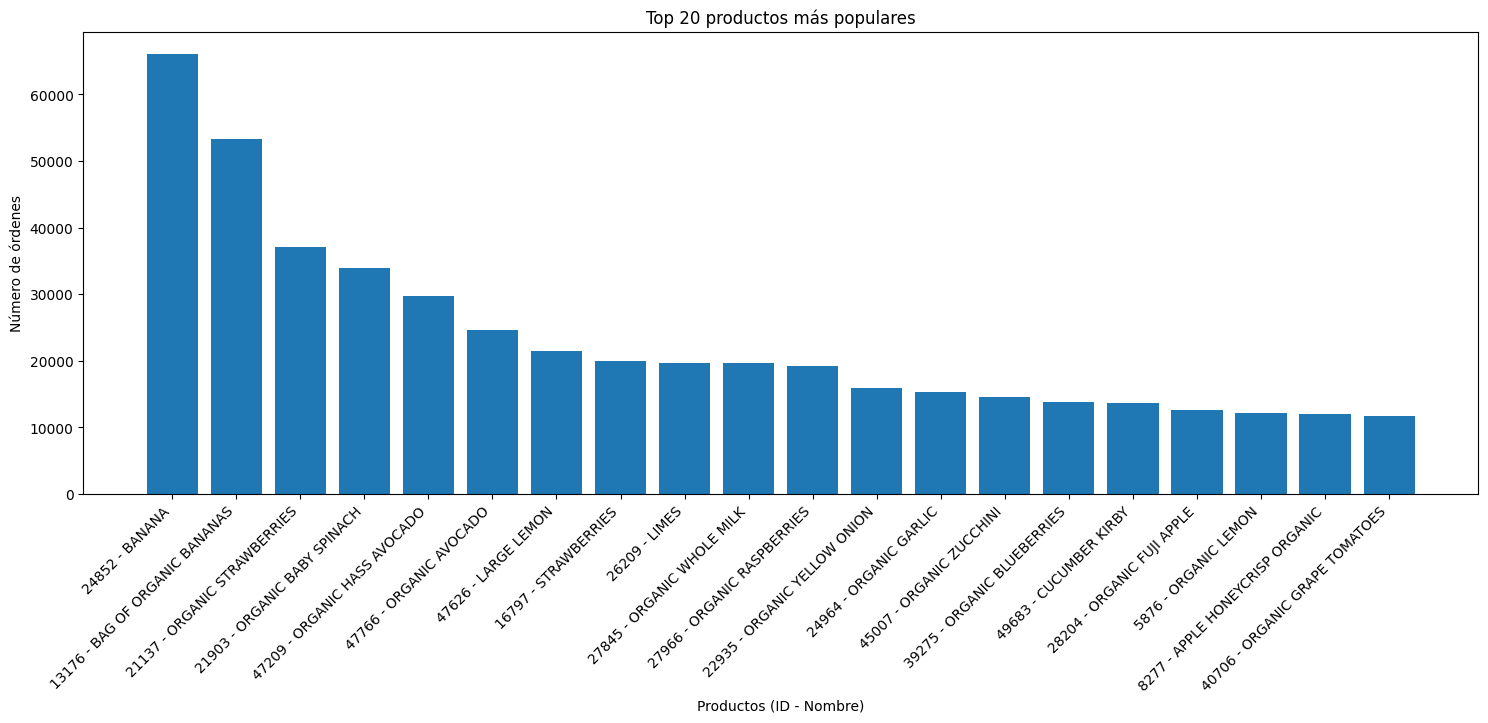

In [ ]:
plt.figure(figsize=(18,6))
plt.bar(top20["product_label"], top20["order_id"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Productos (ID - Nombre)")
plt.ylabel("Número de órdenes")
plt.title("Top 20 productos más populares")
plt.show()

A través de este análisis podemos ver los 20 productos que más se venden, donde en primer lugar tenemos a la banana, seguido de la banana orgánica.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [ ]:
items_per_order = order_products_df.groupby("order_id")["product_id"].count()

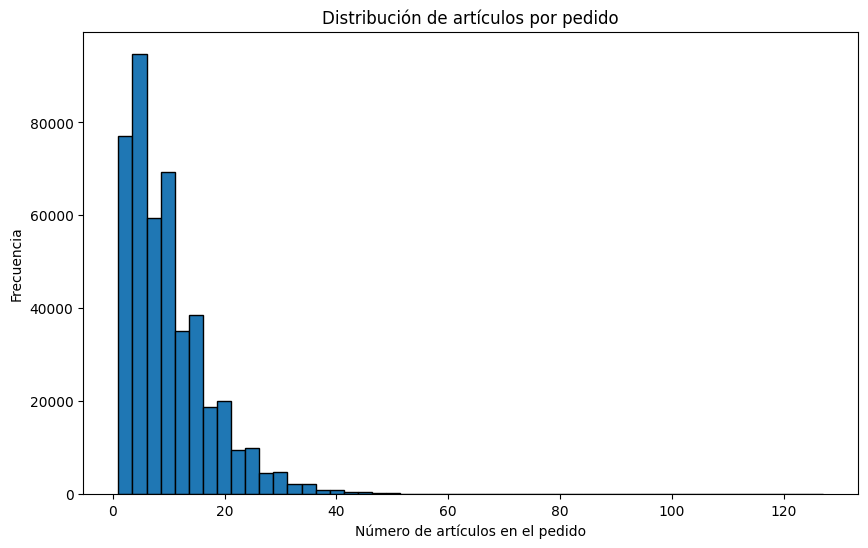

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(items_per_order, bins=50, edgecolor="black")
plt.xlabel("Número de artículos en el pedido")
plt.ylabel("Frecuencia")
plt.title("Distribución de artículos por pedido")
plt.show()

Resulta interesante la gráfica pues muestra que las compras con bajos productos son resaltantes pero, podemos ver que luego hay un aumento que es el pico de frecuencia de ventas y por último una caída razonable a partir de 20 productos en ade

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

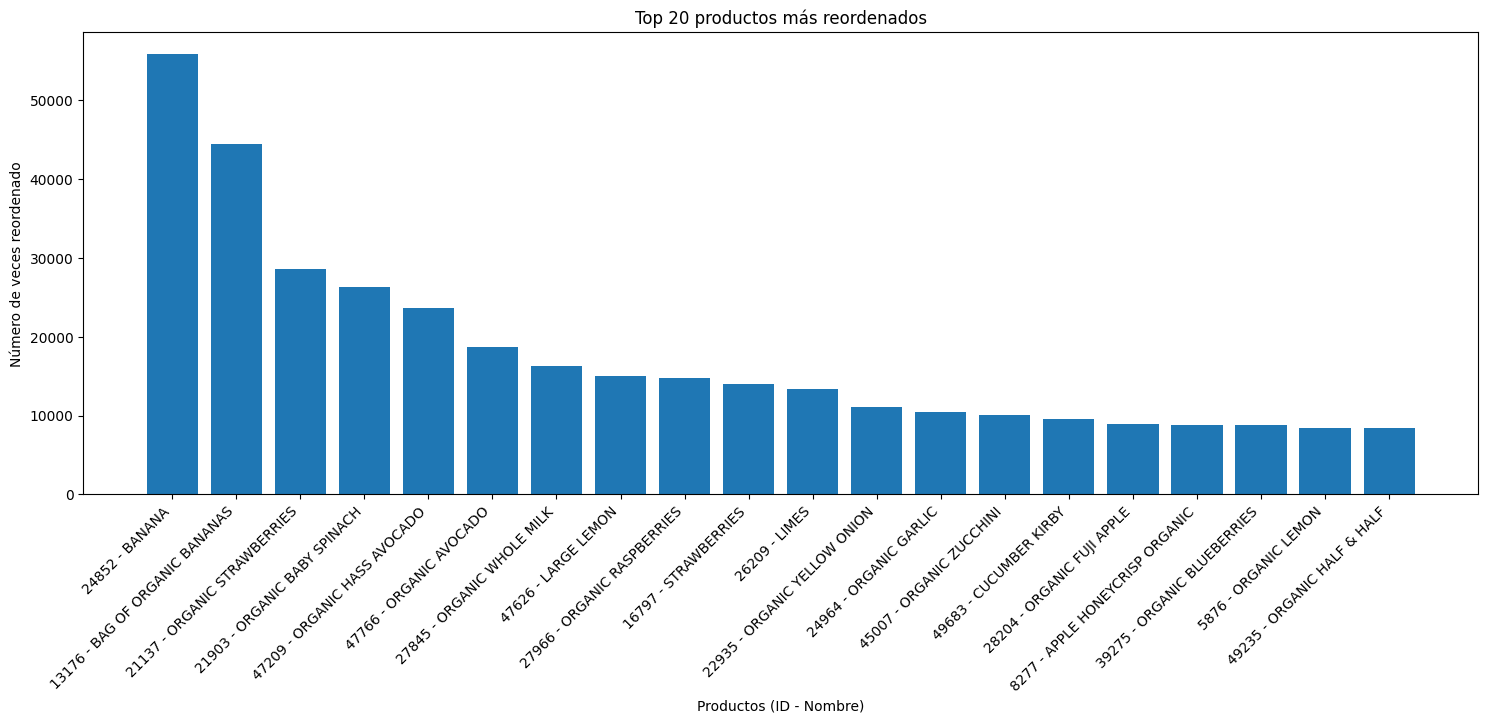

In [ ]:
reorders_per_product = order_products_df.groupby("product_id")["reordered"].sum()

top20_reorders = reorders_per_product.sort_values(ascending=False).head(20).reset_index()

top20_reorders = top20_reorders.merge(products_df, on="product_id", how="left")

top20_reorders["product_label"] = (
    top20_reorders["product_id"].astype(str) + " - " + top20_reorders["product_name"]
)

plt.figure(figsize=(18,6))
plt.bar(top20_reorders["product_label"], top20_reorders["reordered"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Productos (ID - Nombre)")
plt.ylabel("Número de veces reordenado")
plt.title("Top 20 productos más reordenados")
plt.show()

La gráfica se parece mucho a la que se vio en los productos más vendidos. Esto es coherente y por otro lado vemos obviamente una disminución ya que los productos que vuelven a ordenarse suelen ser menores a los vendidos en general.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

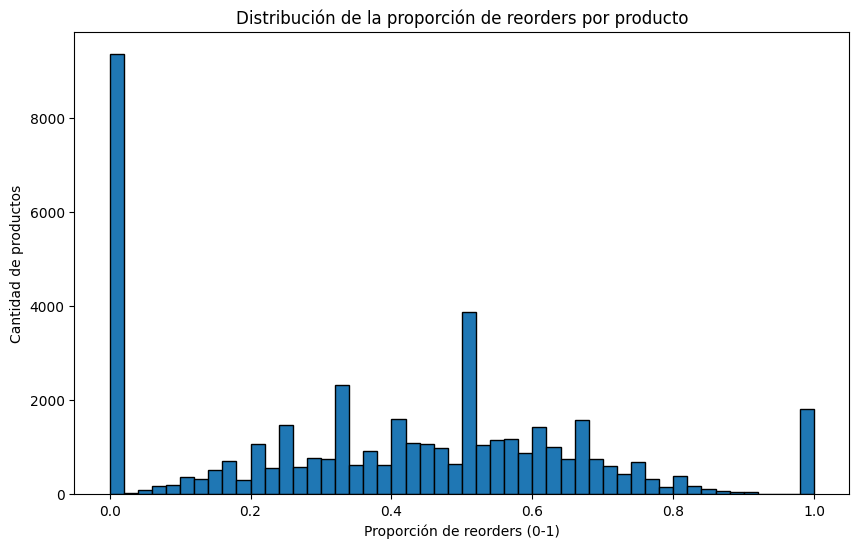

In [ ]:
total_per_product = order_products_df.groupby("product_id")["order_id"].count()

reorders_per_product = order_products_df.groupby("product_id")["reordered"].sum()

reorder_ratio = (reorders_per_product / total_per_product).reset_index()
reorder_ratio.columns = ["product_id", "reorder_ratio"]

reorder_ratio = reorder_ratio.merge(products_df, on="product_id", how="left")

plt.figure(figsize=(10,6))
plt.hist(reorder_ratio["reorder_ratio"], bins=50, edgecolor="black")
plt.xlabel("Proporción de reorders (0-1)")
plt.ylabel("Cantidad de productos")
plt.title("Distribución de la proporción de reorders por producto")
plt.show()

En la gráfica se pueden ver muchos productos que unicamente se piden una sola vez, luego vemos un grueso en los demás que suelen re ordenarse. Por último. Vemos de igual manera un número interesante de productos que su número de ordenes es casi igual al de reordenes.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [ ]:
orders_products_users = order_products_df.merge(
    instacard_df[["order_id", "user_id"]],
    on="order_id", how="left"
)

total_per_user = orders_products_users.groupby("user_id")["product_id"].count()
reorders_per_user = orders_products_users.groupby("user_id")["reordered"].sum()

reorder_ratio_user = (reorders_per_user / total_per_user).reset_index()
reorder_ratio_user.columns = ["user_id", "reorder_ratio"]


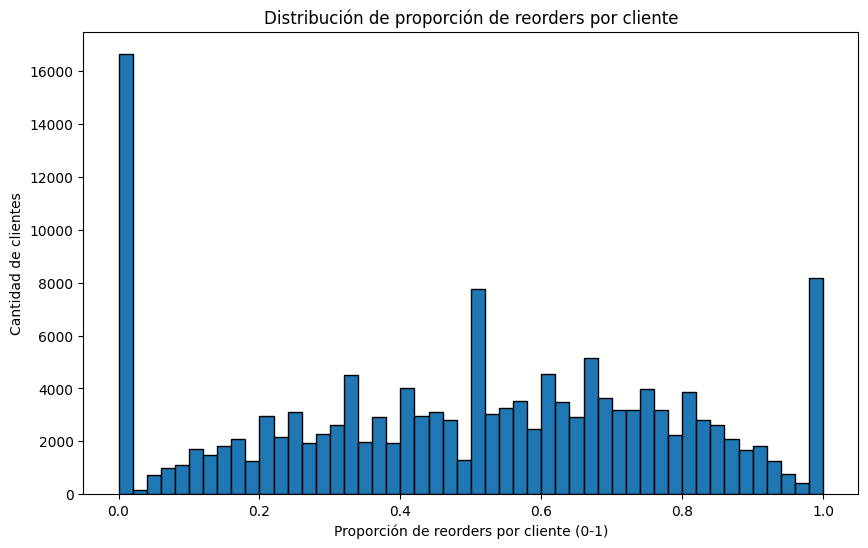

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: reorder_ratio, dtype: float64


In [ ]:
plt.figure(figsize=(10,6))
plt.hist(reorder_ratio_user["reorder_ratio"], bins=50, edgecolor="black")
plt.xlabel("Proporción de reorders por cliente (0-1)")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de proporción de reorders por cliente")
plt.show()

print(reorder_ratio_user["reorder_ratio"].describe())

La distribución confirma que el dataset refleja dos comportamientos extremos muy fuertes (exploradores vs fieles), con una gran masa de clientes en el medio que combinan ambos estilos.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [ ]:
first_in_cart = order_products_df[order_products_df["add_to_cart_order"] == 1]
first_counts = first_in_cart["product_id"].value_counts().head(20)

In [ ]:
top20_first = first_counts.reset_index()
top20_first.columns = ["product_id", "count"]

top20_first = top20_first.merge(products_df[["product_id", "product_name"]],
                                on="product_id", how="left")

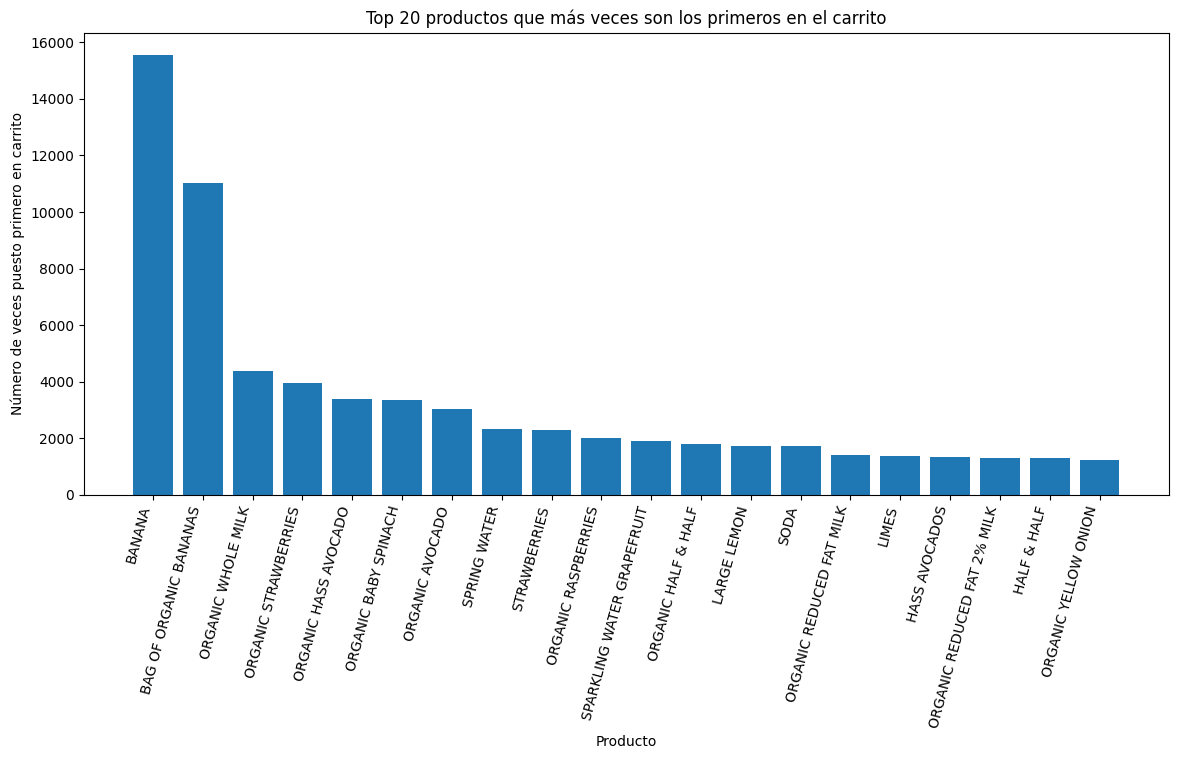

In [ ]:
plt.figure(figsize=(14,6))
plt.bar(top20_first["product_name"], top20_first["count"])
plt.xticks(rotation=75, ha="right")
plt.xlabel("Producto")
plt.ylabel("Número de veces puesto primero en carrito")
plt.title("Top 20 productos que más veces son los primeros en el carrito")
plt.show()

Escribe aquí tus conclusiones

### Conclusion general del proyecto:

Los clientes de Instacart suelen comprar más los fines de semana, sobre todo entre las 10 am. y 5 pm. La mayoría hace pedidos una vez por semana y
repite gran parte de sus productos habituales, especialmente los básicos como leche, pan, huevos, frutas y verduras. Los artículos más populares son bananas,
fresas, espinaca, aguacates y leche orgánica. Los pasillos más importantes son los de frutas, verduras y lácteos. Normalmente los productos de primera necesidad se
agregan primero al carrito, mientras que snacks o bebidas se incluyen después como compras más espontáneas. En general, los datos muestran un hábito de compra regular,
centrado en productos frescos y de uso diario.